<a href="https://colab.research.google.com/github/yuniastariiy/IBM-Data-Analyst---Phyton/blob/main/Final_Assignment_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Create visualizations using Matplotib, Seaborn and Folium**

In [36]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install folium

### Installing Required Libraries

In [37]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import requests
import io

# Importing Data

In [38]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

response = requests.get(URL)
data = io.StringIO(response.text)
df = pd.read_csv(data)

print('Data downloaded and read into a dataframe!')
df.head()

Data downloaded and read into a dataframe!


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


In [39]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,2001.500000,0.214015,101.140170,0.575795,24964.991956,3067.456439,6.064394,40.073903,-0.242001,2.453977,2352.718068
std,12.710467,0.410526,10.601154,0.454477,4888.073433,1139.564637,1.968350,16.249714,0.861268,1.119019,1645.321284
min,1980.000000,0.000000,73.900000,0.000000,8793.663000,1009.000000,3.000000,12.508000,-4.227601,1.000000,102.000000
25%,1990.750000,0.000000,94.035000,0.250000,21453.300500,2083.500000,4.000000,27.237500,-0.574049,1.600000,793.950000
50%,2001.500000,0.000000,100.740000,0.500000,25038.691500,3072.000000,6.000000,39.214500,-0.013162,2.300000,2182.600000
75%,2012.250000,0.000000,108.240000,0.750000,28131.684750,4067.250000,8.000000,53.506500,0.388932,2.900000,3614.800000
max,2023.000000,1.000000,131.670000,1.500000,44263.657000,4983.000000,9.000000,70.374000,0.815074,6.000000,21147.000000


In [40]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

# Creating Visualizations for Data Analysis

### TASK 1.1: Develop a *Line chart* using the functionality of pandas to show how automobile sales fluctuate from year to year


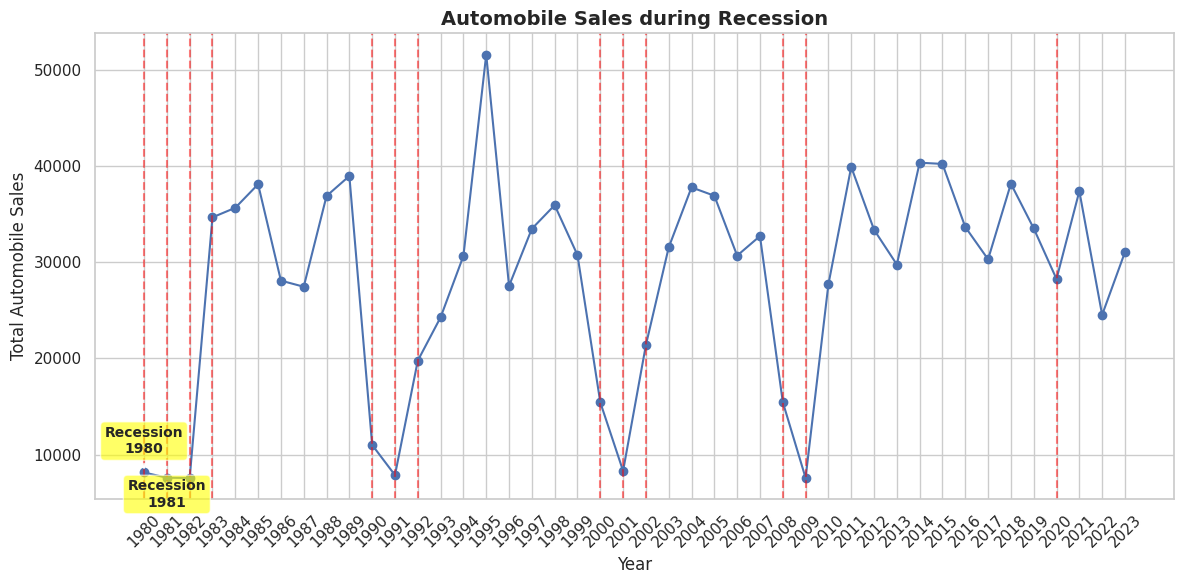

In [41]:
sales_by_year = df.groupby('Year')[['Automobile_Sales', 'Recession']].agg({
    'Automobile_Sales': 'sum',
    'Recession': 'max'
}).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(sales_by_year['Year'], sales_by_year['Automobile_Sales'], marker='o', linestyle='-')

plt.xticks(sales_by_year['Year'], rotation=45)

recession_years = sales_by_year[sales_by_year['Recession'] == 1]['Year'].tolist()
for year in recession_years:
    plt.axvline(x=year, color='red', linestyle='--', alpha=0.5)

for i, year in enumerate(recession_years[:2]):
    value = sales_by_year[sales_by_year['Year'] == year]['Automobile_Sales'].values[0]
    offset = 2000 if i % 2 == 0 else -3000
    plt.annotate(f'Recession\n{year}',
                 xy=(year, value),
                 xytext=(year, value + offset),
                 ha='center',
                 fontsize=10,
                 fontweight='bold',
                 arrowprops=dict(facecolor='black', arrowstyle='->', linewidth=1.2),
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.6))

plt.title('Automobile Sales during Recession', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Automobile Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

- Overall Sales Trend: The total automobile sales fluctuate significantly year over year. There are periods of strong growth followed by sharp declines.
- Recession Impact (Marked by Red Dashed Lines): The red dashed lines clearly highlight years of recession. In almost all marked recession periods (e.g., 1980-1981, early 1990s, early 2000s, 2008-2009, 2020), there is a noticeable sharp drop or a period of suppressed automobile sales. The decline in 2008-2009 is particularly severe, indicating the profound impact of that recession on the auto industry.
- Recovery after Recession: Sales generally show a recovery trend in the years immediately following a recession, though the pace and extent of recovery vary.
- Pre-Recession Peaks: Often, sales reach a peak just before a recession (e.g., late 1990s before early 2000s recession, mid-2000s before 2008 recession).

### TASK 1.2: Plot different lines for categories of vehicle type and analyse the trend to answer the question Is there a noticeable difference in sales trends between different vehicle types during recession periods?

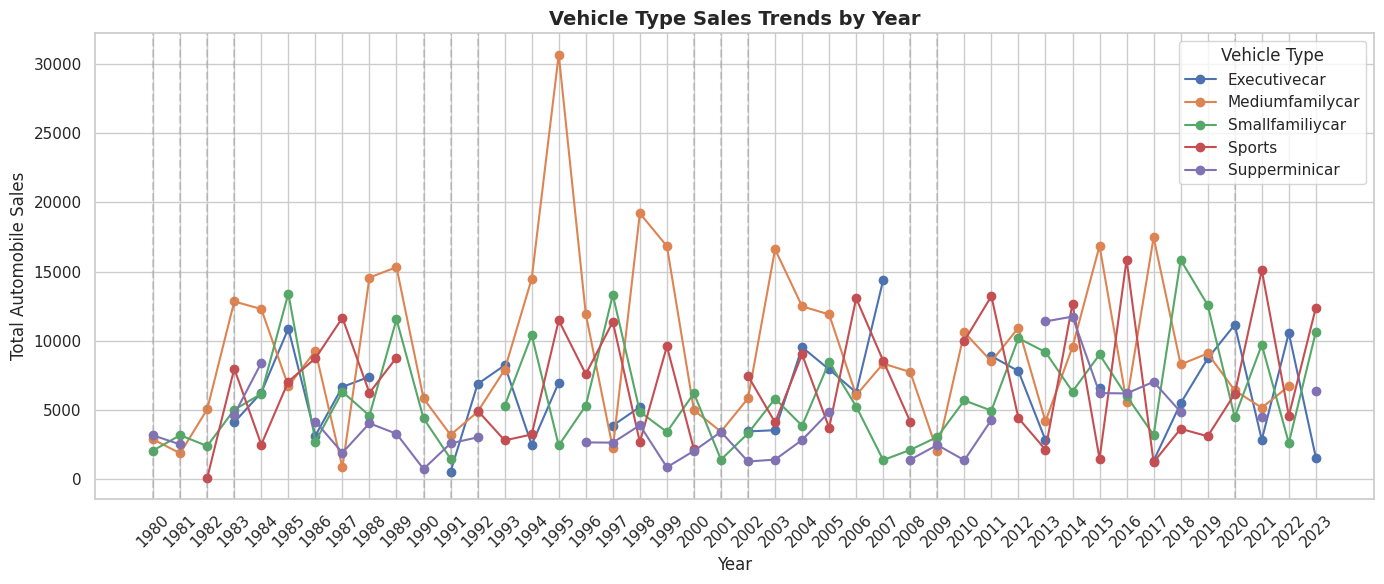

In [42]:
sales_by_type_year = df.groupby(['Year', 'Vehicle_Type'])['Automobile_Sales'].sum().reset_index()

pivot_table = sales_by_type_year.pivot(index='Year', columns='Vehicle_Type', values='Automobile_Sales')

plt.figure(figsize=(14, 6))

for column in pivot_table.columns:
    plt.plot(pivot_table.index, pivot_table[column], marker='o', label=column)

recession_years = df[df['Recession'] == 1]['Year'].unique()
for year in recession_years:
    plt.axvline(x=year, color='gray', linestyle='--', alpha=0.3)

plt.title('Vehicle Type Sales Trends by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Automobile Sales')
plt.xticks(pivot_table.index, rotation=45)
plt.legend(title='Vehicle Type')
plt.grid(True)
plt.tight_layout()
plt.show()

- Dominance of Family Cars: "Mediumfamilycar" and "Smallfamilycar" generally show the highest total automobile sales across most years, frequently reaching peaks above 10,000 to 15,000 units, and even exceeding 30,000 for "Mediumfamilycar" around 1994-1995. This indicates they are consistently popular segments.
- Fluctuating Sales: All vehicle types exhibit significant year-to-year fluctuations in sales, highlighting the dynamic nature of the automobile market.
"Supperminicar" Performance: "Supperminicar" sales are competitive, often fluctuating within a similar range as "Smallfamilycar" but generally peaking lower than "Mediumfamilycar".
- Lower Sales for Niche/Luxury: "Executivecar" and "Sports" cars consistently have lower total sales volumes compared to family and supermini cars throughout the years. Their peaks are significantly lower, often staying below 10,000 units.
- Peak Sales Periods: There are noticeable spikes for certain vehicle types in specific years (e.g., "Mediumfamilycar" in mid-90s, "Executivecar" and "Sports" showing some peaks in the late 2000s and mid-2010s but still relatively low compared to family cars).

### TASK 1.3: Use the functionality of **Seaborn Library** to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.

<ipython-input-43-1712828050>:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(


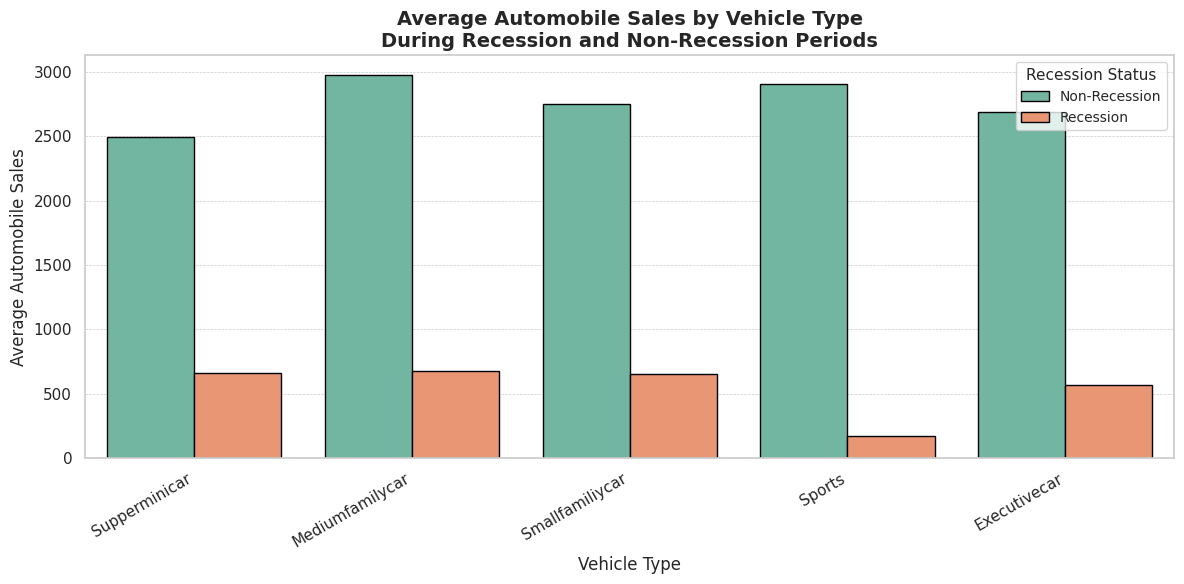

In [43]:
# Set style and color palette
sns.set(style="whitegrid", palette="Set2")

# Set figure size
plt.figure(figsize=(12, 6))

# Create barplot
barplot = sns.barplot(
    x='Vehicle_Type',
    y='Automobile_Sales',
    hue='Recession',
    data=df,
    estimator='mean',
    ci=None,  # remove confidence intervals for cleaner look
    edgecolor='black'
)

# Customize labels and title
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Average Automobile Sales', fontsize=12)
plt.title('Average Automobile Sales by Vehicle Type\nDuring Recession and Non-Recession Periods', fontsize=14, fontweight='bold')

# Customize legend
plt.legend(
    title='Recession Status',
    labels=['Non-Recession', 'Recession'],
    title_fontsize='11',
    fontsize='10',
    loc='upper right'
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right')

# Add grid only on y-axis
plt.grid(axis='y', linestyle='--', linewidth=0.5)

# Tight layout to prevent clipping
plt.tight_layout()

- Significant Drop in Sales During Recession: For every single vehicle type, there is a dramatic and consistent decrease in average automobile sales during recession periods (coral bars) compared to non-recession periods (teal bars). This highlights the severe negative impact of economic downturns on the entire automotive market.

- Family Cars Dominate Overall Sales: "Mediumfamilycar" and "Smallfamilycar" consistently show the highest average sales volumes during non-recession periods, indicating their strong market demand in a healthy economy. "Supperminicar" also performs well, though slightly less than the larger family cars.

- Luxury/Niche Cars Most Vulnerable:
"Sports" cars experience the most drastic proportional decline in sales during a recession. Their average sales plummet to extremely low levels (barely above 0) during recessions, making them highly vulnerable to economic shifts.
"Executivecar" also faces a very substantial drop in average sales during recessions, second only to "Sports" cars in terms of vulnerability.
Relative Resilience of Mass-Market Vehicles: While "Supperminicar," "Mediumfamilycar," and "Smallfamilycar" all see their sales reduced during recessions, their average sales figures (coral bars) remain significantly higher than those of "Sports" or "Executivecar" during the same period. This suggests that these mass-market segments are relatively more resilient, likely due to being considered more essential or practical purchases.

- Clear Distinction Between Economic Conditions: The visual separation between the teal (non-recession) and coral (recession) bars for each vehicle type clearly illustrates how directly and negatively economic recessions impact average sales across the board.









### TASK 1.4: Use sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period.

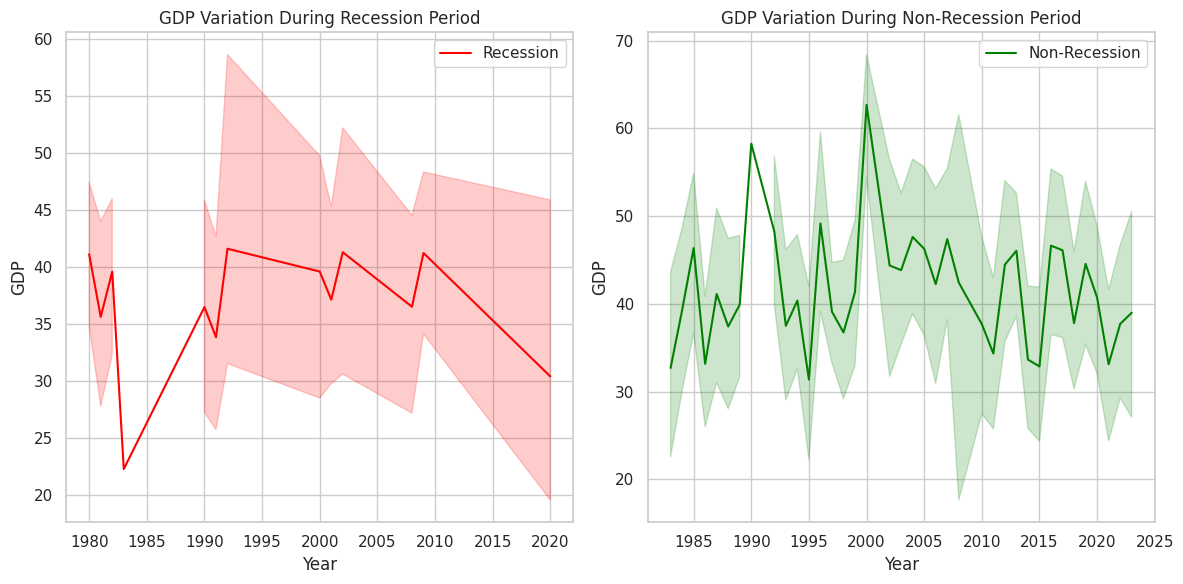

In [44]:
# Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

# Create figure
fig = plt.figure(figsize=(12, 6))

# Subplot 1 - Recession period
ax0 = fig.add_subplot(1, 2, 1)  # (1 row, 2 columns, 1st plot)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0, color='red')
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation During Recession Period')
ax0.grid(True)

# Subplot 2 - Non-Recession period
ax1 = fig.add_subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1, color='green')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation During Non-Recession Period')
ax1.grid(True)

plt.tight_layout()
plt.show()

 The two plots starkly contrast economic health. Recessions are characterized by lower GDP baselines, sharp declines, and higher volatility, while non-recession periods generally exhibit higher GDP levels and more sustained, though fluctuating, growth.

### TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.


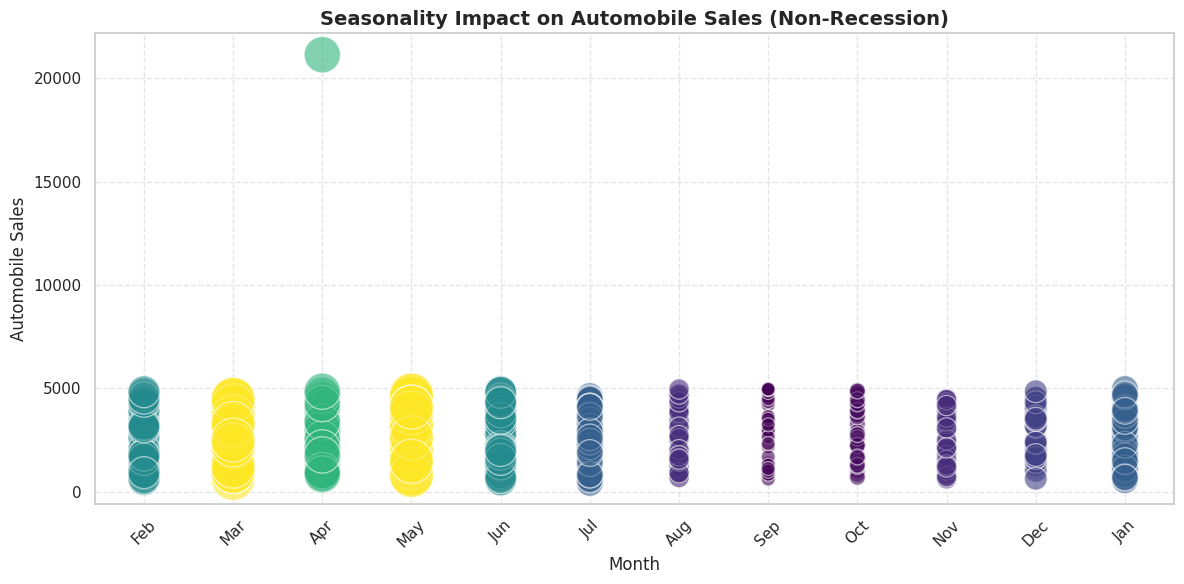

In [45]:
non_rec_data = df[df['Recession'] == 0]

size = non_rec_data['Seasonality_Weight']

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=non_rec_data,
    x='Month',
    y='Automobile_Sales',
    size='Seasonality_Weight',
    hue='Seasonality_Weight',
    palette='viridis',
    legend=False,
    sizes=(100, 1000),
    alpha=0.6
)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Automobile Sales', fontsize=12)
plt.title('Seasonality Impact on Automobile Sales (Non-Recession)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- Peak Sales in Spring (April): There is a very strong seasonal peak in automobile sales during April, with one particular data point showing sales significantly above 20,000 units, which is much higher than any other month.
- Strong Spring Months: March and May also consistently show higher sales activity compared to the rest of the year, often reaching around 5,000 units. This suggests a general "spring selling season."
- Lower Sales in Late Summer/Fall/Winter: Sales generally appear lower and more consistent from July through January, typically staying below 5,000 units.
- Consistency within Months: For most months outside the peak spring period, sales figures tend to cluster more closely, indicating less variability within those months, albeit at lower overall levels.

 ### TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the correlation between average vehicle price relate to the sales volume during recessions.

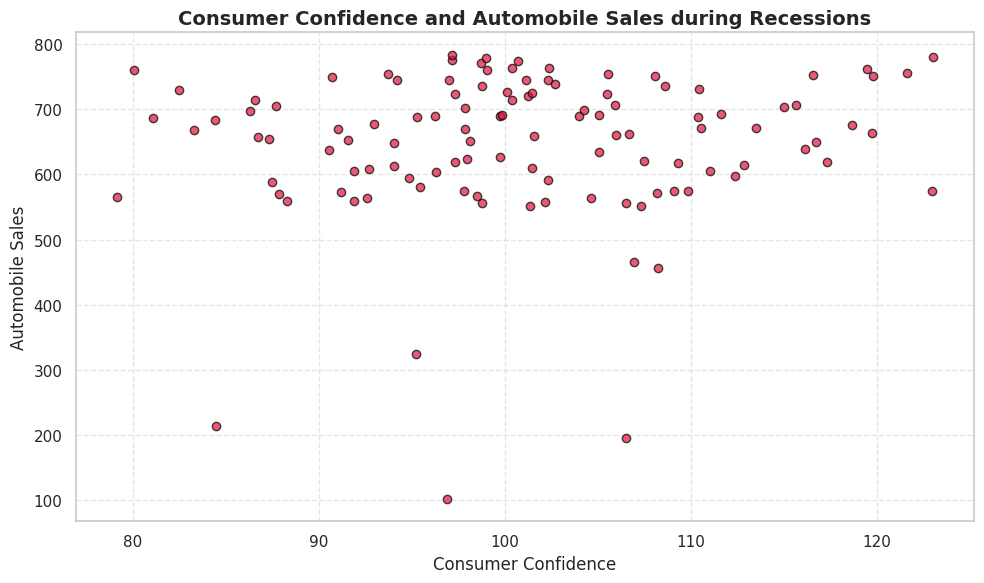

In [46]:
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
plt.scatter(
    rec_data['Consumer_Confidence'],
    rec_data['Automobile_Sales'],
    color='crimson',
    alpha=0.7,
    edgecolors='black'
)

plt.xlabel('Consumer Confidence', fontsize=12)
plt.ylabel('Automobile Sales', fontsize=12)
plt.title('Consumer Confidence and Automobile Sales during Recessions', fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- Positive Correlation at Lower Confidence: At lower levels of consumer confidence (e.g., below 95), there appears to be a general positive relationship: as confidence increases, automobile sales tend to increase, albeit with some variability.
- Plateau/Saturation at Higher Confidence: Once consumer confidence reaches a certain threshold (roughly above 95-100), automobile sales tend to plateau. Most data points cluster in the higher sales range (above 600 units), regardless of further increases in confidence up to about 120. This suggests that while minimum confidence is crucial, extremely high confidence doesn't necessarily lead to proportionally higher sales during recessions, possibly indicating a sales ceiling or other limiting factors.
- Outliers with Low Sales: There are a few instances where automobile sales are very low (e.g., around 100-300 units) even when consumer confidence is at moderate levels (around 95-100), indicating that other severe factors might be at play during specific recessionary periods.

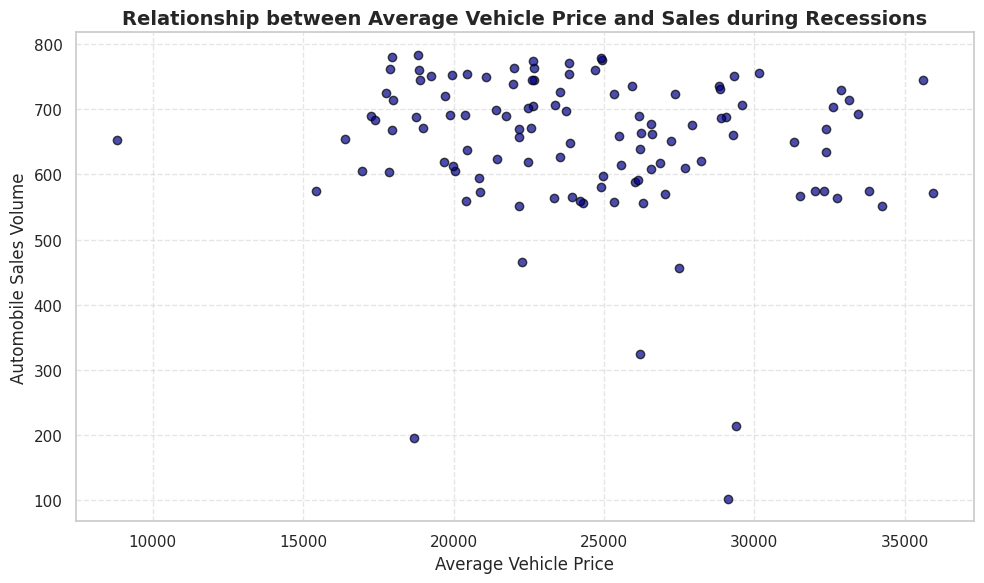

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(
    rec_data['Price'],
    rec_data['Automobile_Sales'],
    color='darkblue',
    alpha=0.7,
    edgecolors='black'
)

plt.xlabel('Average Vehicle Price', fontsize=12)
plt.ylabel('Automobile Sales Volume', fontsize=12)
plt.title('Relationship between Average Vehicle Price and Sales during Recessions', fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


- No Strong Linear Correlation: During recessions, there isn't a clear positive or negative linear relationship between average vehicle price and sales volume. Sales do not consistently increase or decrease as price changes.
- Sales Clustered in Mid-to-High Range: Most sales volumes (Y-axis) during recessions are clustered in a range between approximately 550 and 800 units, for average vehicle prices ranging from about 17,000 to 35,000.
- Low Sales Across Price Points: Very low sales volumes (e.g., 100-300 units) can occur at various average price points, indicating that low sales are not exclusively tied to either very high or very low average prices during a recession.

 ### TASK 1.7: Create a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.

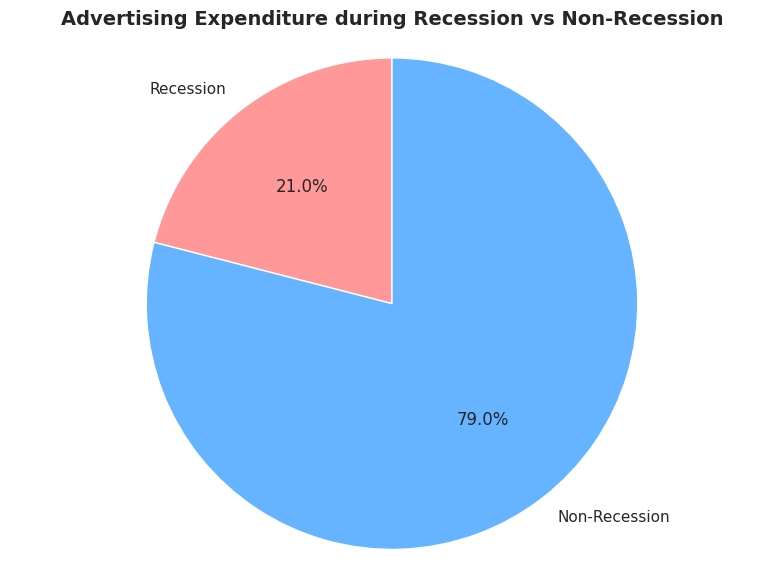

In [48]:
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
colors = ['#ff9999', '#66b3ff']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Advertising Expenditure during Recession vs Non-Recession', fontsize=14, fontweight='bold')
plt.axis('equal')

plt.tight_layout()
plt.show()

The vast majority of advertising expenditure (79.0%) occurs during non-recession periods, while only a small fraction (21.0%) is spent during recessions. This indicates that companies drastically cut advertising budgets during economic downturns.

TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period.

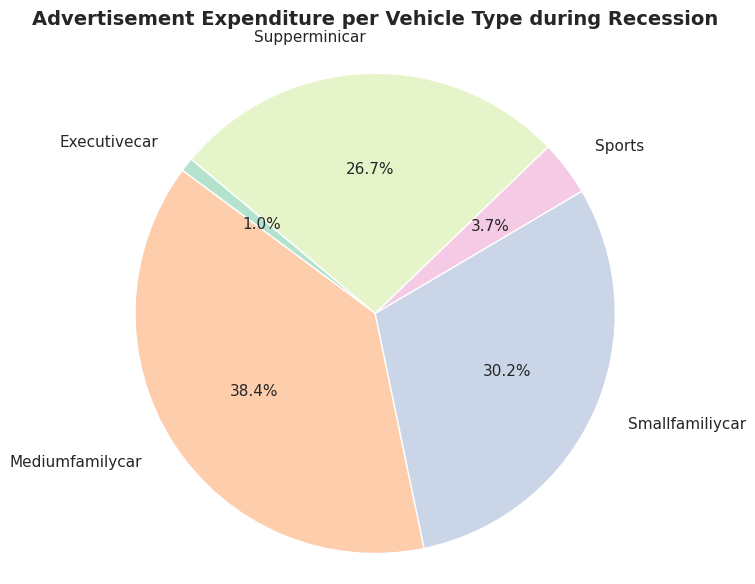

In [49]:
Rdata = df[df['Recession'] == 1]

VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

colors = plt.cm.Pastel2.colors

plt.figure(figsize=(8, 6))

wedges, texts, autotexts = plt.pie(
    VTexpenditure.values,
    labels=VTexpenditure.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    labeldistance=1.15,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 11}
)

plt.title(
    'Advertisement Expenditure per Vehicle Type during Recession',
    fontsize=14,
    fontweight='bold',
    pad=20,
    loc='center'
)

plt.axis('equal')
plt.tight_layout()
plt.show()

During recessions, advertising expenditure is heavily concentrated on "Mediumfamilycar" (38.4%), "Smallfamilycar" (30.2%), and "Supperminicar" (26.7%), collectively accounting for over 95% of the ad spend. "Executivecar" (1.0%) and "Sports" (3.7%) receive minimal advertising investment during these periods. This indicates a strategic focus on promoting more essential and mass-market vehicle types during economic downturns.

 ### TASK 1.9: Develop a lineplot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.

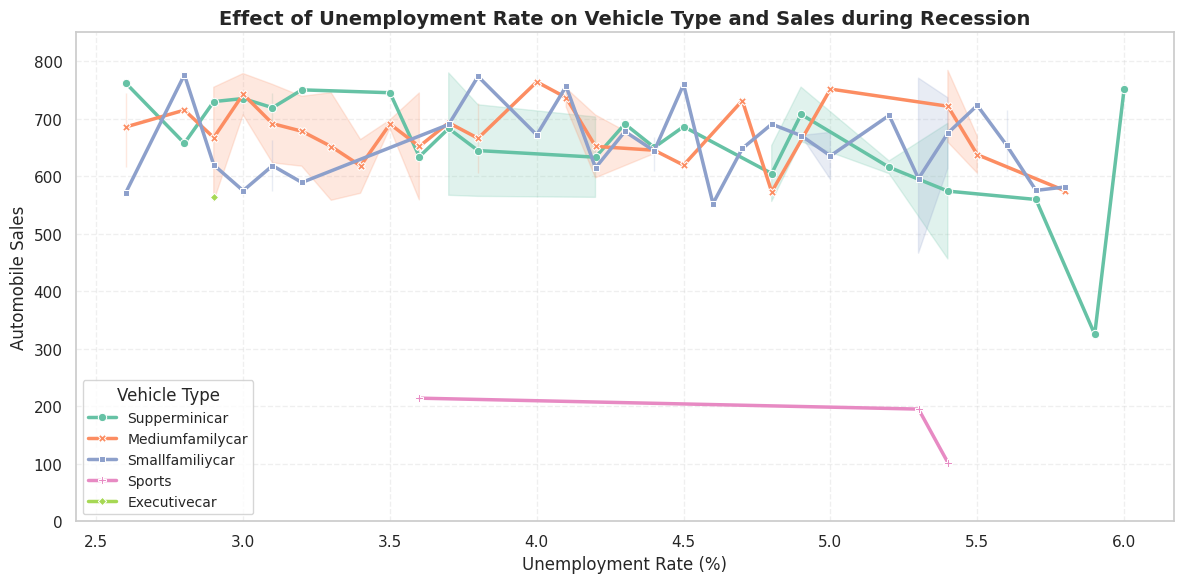

In [50]:
df_rec = df[df['Recession'] == 1]

sns.set(style='whitegrid')

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_rec,
    x='unemployment_rate',
    y='Automobile_Sales',
    hue='Vehicle_Type',
    style='Vehicle_Type',
    markers=True,
    dashes=False,
    palette='Set2',
    linewidth=2.5
)

plt.ylim(0, 850)
plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Automobile Sales', fontsize=12)
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales during Recession', fontsize=14, fontweight='bold')

plt.legend(title='Vehicle Type', title_fontsize='12', fontsize='10', loc='best')

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


- "Sports" and "Executivecar" consistently maintain very low sales volumes (mostly below 250 units) across varying unemployment rates during recessions, indicating their extreme vulnerability regardless of the unemployment level.
- For "Supperminicar", "Mediumfamilycar", and "Smallfamilycar", sales volumes are significantly higher (generally between 550 and 750 units) than luxury/niche cars during recessions.
- For these higher-volume family cars, there isn't a simple strong inverse linear relationship with the unemployment rate; sales fluctuate, but tend to be sustained at higher levels than luxury cars even with rising unemployment, though "Supperminicar" shows a drop at very high unemployment rates.